<a href="https://colab.research.google.com/github/rohit-khaire/dog-breed-detection/blob/main/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐾 PawID — Dog Breed Classifier Training
## Transfer Learning with MobileNetV2 | Stanford Dogs + Indian Breeds

**What this notebook does:**
1. Downloads the Stanford Dogs Dataset (120 breeds, ~20,000 images)
2. Adds Indian dog breed images
3. Fine-tunes MobileNetV2 (pre-trained on ImageNet)
4. Trains for dog-specific classification
5. Exports the model for use in the web app

> ⚡ **Enable GPU first**: Runtime → Change runtime type → GPU

In [7]:
# ============================================================
# CELL 1 — Install Dependencies
# ============================================================
!pip install tensorflow==2.13.0 tensorflow-hub matplotlib seaborn scikit-learn pillow tqdm --quiet
print('✅ Dependencies installed')

ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.13.0
✅ Dependencies installed


In [8]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import os, json, shutil, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
)
from sklearn.metrics import classification_report, confusion_matrix

print(f'✅ TensorFlow {tf.__version__}')
print(f'✅ GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ TensorFlow 2.19.0
✅ GPU available: True


In [9]:
import os
CONFIG = {
    'IMG_SIZE': 224,          # MobileNetV2 common size
    'BATCH_SIZE': 32,
    'EPOCHS_FROZEN': 10,      # Phase 1: train only top layers
    'EPOCHS_UNFROZEN': 20,    # Phase 2: fine-tune whole model
    'LEARNING_RATE': 1e-3,
    'FINE_TUNE_LR': 1e-5,
    'DROPOUT': 0.4,
    'DATA_DIR': '/content/dog_data',
    'MODEL_SAVE': '/content/pawid_model',
    'SEED': 42,
}

os.makedirs(CONFIG['DATA_DIR'], exist_ok=True)
os.makedirs(CONFIG['MODEL_SAVE'], exist_ok=True)
print('✅ Config set')

✅ Config set


In [10]:
# ============================================================
# CELL 4 — Download Stanford Dogs Dataset
# ============================================================
import tarfile

STANFORD_IMAGES_URL = 'http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar'
STANFORD_ANNOT_URL  = 'http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar'

def download_and_extract(url, dest_dir):
    filename = url.split('/')[-1]
    filepath = os.path.join(dest_dir, filename)
    if not os.path.exists(filepath):
        print(f'⬇️  Downloading {filename}...')
        urllib.request.urlretrieve(url, filepath)
        print(f'✅ Downloaded {filename}')
    else:
        print(f'✅ Already downloaded: {filename}')
    print(f'📦 Extracting {filename}...')
    with tarfile.open(filepath) as tar:
        tar.extractall(dest_dir)
    print(f'✅ Extracted {filename}')

download_and_extract(STANFORD_IMAGES_URL, CONFIG['DATA_DIR'])

# Verify
images_dir = os.path.join(CONFIG['DATA_DIR'], 'Images')
breeds = sorted(os.listdir(images_dir))
print(f'\n✅ Stanford Dogs Dataset ready')
print(f'📊 Total breeds found: {len(breeds)}')
print(f'📸 Sample breeds: {breeds[:5]}')

⬇️  Downloading images.tar...
✅ Downloaded images.tar
📦 Extracting images.tar...


/tmp/ipykernel_854/3929972837.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dest_dir)


✅ Extracted images.tar

✅ Stanford Dogs Dataset ready
📊 Total breeds found: 120
📸 Sample breeds: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu']


In [11]:
# ============================================================
# CELL 5 — Clean and Restructure Dataset
# Maps Stanford folder names (n02085620-Chihuahua) → clean names (Chihuahua)
# ============================================================
import re

def clean_breed_name(folder_name):
    """Convert n02085620-Chihuahua → Chihuahua"""
    name = re.sub(r'^n\d+-', '', folder_name)
    name = name.replace('_', ' ').title()
    return name

CLEAN_DIR = os.path.join(CONFIG['DATA_DIR'], 'clean_dataset')
os.makedirs(CLEAN_DIR, exist_ok=True)

breed_name_map = {}
total_images = 0

for folder in tqdm(breeds, desc='Organizing breeds'):
    clean_name = clean_breed_name(folder)
    breed_name_map[folder] = clean_name
    src = os.path.join(images_dir, folder)
    dst = os.path.join(CLEAN_DIR, clean_name)
    if not os.path.exists(dst):
        shutil.copytree(src, dst)
    count = len(os.listdir(dst))
    total_images += count

print(f'\n✅ Dataset cleaned and organized')
print(f'📊 Total breeds: {len(breeds)}')
print(f'📸 Total images: {total_images}')
print(f'📈 Avg images/breed: {total_images // len(breeds)}')

Organizing breeds: 100%|██████████| 120/120 [00:06<00:00, 17.16it/s]


✅ Dataset cleaned and organized
📊 Total breeds: 120
📸 Total images: 20580
📈 Avg images/breed: 171


In [12]:
# ============================================================
# CELL 6 — Add Indian Dog Breeds
# We use Bing Image Downloader to get images for Indian breeds
# ============================================================
!pip install bing-image-downloader --quiet
from bing_image_downloader import downloader

INDIAN_BREEDS = [
    'Rajapalayam dog',
    'Mudhol Hound dog',
    'Indian Pariah dog',
    'Kanni dog breed',
    'Chippiparai dog',
    'Rampur Greyhound dog',
    'Jonangi dog breed',
    'Bakharwal dog',
    'Kombai dog breed',
    'Mahratta Greyhound dog',
]

INDIAN_DIR = os.path.join(CLEAN_DIR)

for breed_query in INDIAN_BREEDS:
    breed_name = breed_query.replace(' dog', '').replace(' breed', '').title()
    save_path = os.path.join(CLEAN_DIR, breed_name)
    if os.path.exists(save_path) and len(os.listdir(save_path)) >= 50:
        print(f'✅ Already have {breed_name}')
        continue
    print(f'⬇️  Downloading images for: {breed_name}')
    try:
        downloader.download(
            breed_query,
            limit=150,
            output_dir=CLEAN_DIR,
            adult_filter_off=True,
            force_replace=False,
            timeout=30,
            verbose=False
        )
        # Rename folder to clean name
        downloaded = os.path.join(CLEAN_DIR, breed_query)
        if os.path.exists(downloaded):
            os.rename(downloaded, save_path)
        count = len(os.listdir(save_path)) if os.path.exists(save_path) else 0
        print(f'  ✅ {breed_name}: {count} images')
    except Exception as e:
        print(f'  ⚠️  Could not download {breed_name}: {e}')

print('\n✅ Indian breeds added')

⬇️  Downloading images for: Rajapalayam
[%] Downloading Images to /content/dog_data/clean_dataset/Rajapalayam dog
[Error]Invalid image, not saving https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=2438440619423433809

[!] Issue getting: https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=2438440619423433809
[!] Error:: Invalid image, not saving https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=2438440619423433809

[!] Issue getting: https://images.happypet.care/images/20163/file_1725043405157.webp
[!] Error:: <urlopen error [Errno -2] Name or service not known>
[!] Issue getting: https://images.happypet.care/images/20153/file_1698216885910.webp
[!] Error:: <urlopen error [Errno -2] Name or service not known>
[Error]Invalid image, not saving https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=351319888887283&amp;get_thumbnail=1

[!] Issue getting: https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=351319888887283&a

In [13]:
# ============================================================
# CELL 7 — Validate & Filter Dataset
# Remove corrupt images, ensure minimum images per breed
# ============================================================
from PIL import Image

MIN_IMAGES_PER_BREED = 50
valid_breeds = []
removed_corrupt = 0
removed_breeds = []

all_breed_dirs = sorted([
    d for d in os.listdir(CLEAN_DIR)
    if os.path.isdir(os.path.join(CLEAN_DIR, d))
])

for breed in tqdm(all_breed_dirs, desc='Validating'):
    breed_path = os.path.join(CLEAN_DIR, breed)
    valid_count = 0
    for img_file in os.listdir(breed_path):
        img_path = os.path.join(breed_path, img_file)
        try:
            with Image.open(img_path) as img:
                img.verify()
            valid_count += 1
        except Exception:
            os.remove(img_path)
            removed_corrupt += 1
    if valid_count >= MIN_IMAGES_PER_BREED:
        valid_breeds.append(breed)
    else:
        removed_breeds.append((breed, valid_count))

print(f'\n✅ Validation complete')
print(f'📊 Valid breeds: {len(valid_breeds)}')
print(f'🗑️  Corrupt images removed: {removed_corrupt}')
if removed_breeds:
    print(f'⚠️  Breeds with too few images (skipped): {removed_breeds[:5]}')

# Save breed list
with open(os.path.join(CONFIG['MODEL_SAVE'], 'breed_classes.json'), 'w') as f:
    json.dump(valid_breeds, f, indent=2)
print(f'💾 Breed list saved: {len(valid_breeds)} breeds')

Validating: 100%|██████████| 130/130 [00:02<00:00, 58.54it/s]


✅ Validation complete
📊 Valid breeds: 130
🗑️  Corrupt images removed: 0
💾 Breed list saved: 130 breeds


In [14]:
# ============================================================
# CELL 8 — Train/Val/Test Split
# ============================================================
import random
from sklearn.model_selection import train_test_split

SPLIT_DIR = os.path.join(CONFIG['DATA_DIR'], 'split')
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(SPLIT_DIR, split), exist_ok=True)

random.seed(CONFIG['SEED'])

for breed in tqdm(valid_breeds, desc='Splitting dataset'):
    breed_path = os.path.join(CLEAN_DIR, breed)
    images = [
        f for f in os.listdir(breed_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
    ]
    random.shuffle(images)

    n = len(images)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)
    splits = {
        'train': images[:train_end],
        'val':   images[train_end:val_end],
        'test':  images[val_end:],
    }

    for split_name, split_files in splits.items():
        dest_dir = os.path.join(SPLIT_DIR, split_name, breed)
        os.makedirs(dest_dir, exist_ok=True)
        for fname in split_files:
            shutil.copy2(
                os.path.join(breed_path, fname),
                os.path.join(dest_dir, fname)
            )

# Count
for split in ['train', 'val', 'test']:
    count = sum(
        len(os.listdir(os.path.join(SPLIT_DIR, split, b)))
        for b in os.listdir(os.path.join(SPLIT_DIR, split))
    )
    print(f'  {split}: {count} images')
print('✅ Dataset split complete (70% train / 15% val / 15% test)')

Splitting dataset: 100%|██████████| 130/130 [00:07<00:00, 16.83it/s]


  train: 15405 images
  val: 3304 images
  test: 3371 images
✅ Dataset split complete (70% train / 15% val / 15% test)


In [15]:
# ============================================================
# CELL 9 — Data Augmentation & Loaders
# ============================================================
IMG_SIZE = CONFIG['IMG_SIZE']
BATCH    = CONFIG['BATCH_SIZE']

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=True,
    seed=CONFIG['SEED']
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print(f'\n✅ Data generators ready')
print(f'📊 Number of classes: {NUM_CLASSES}')
print(f'📸 Training steps/epoch: {len(train_gen)}')

# Save class index map
class_indices = {v: k for k, v in train_gen.class_indices.items()}
with open(os.path.join(CONFIG['MODEL_SAVE'], 'class_indices.json'), 'w') as f:
    json.dump(class_indices, f, indent=2)
print('💾 Class indices saved')

Found 15331 images belonging to 130 classes.
Found 3290 images belonging to 130 classes.
Found 3358 images belonging to 130 classes.

✅ Data generators ready
📊 Number of classes: 130
📸 Training steps/epoch: 480
💾 Class indices saved


In [16]:
# ============================================================
# CELL 10 — Build the Model (MobileNetV2 + Transfer Learning)
# ============================================================
from tensorflow.keras.applications import MobileNetV2

def build_model(num_classes, dropout=0.4):
    # Load MobileNetV2 pre-trained on ImageNet, exclude top layers
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'], 3)
    )
    base_model.trainable = False  # Freeze for Phase 1

    inputs = keras.Input(shape=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'], 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(dropout * 0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(NUM_CLASSES, CONFIG['DROPOUT'])

model.compile(
    optimizer=keras.optimizers.Adam(CONFIG['LEARNING_RATE']),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

model.summary()
print(f'\n✅ Model built — {model.count_params():,} parameters')
print(f'🔒 Base model frozen: {not base_model.trainable}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 130)            │        33,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,083,714 (11.76 MB)

 Trainable params: 823,170 (3.14 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


✅ Model built — 3,083,714 parameters
🔒 Base model frozen: True


In [17]:
# ============================================================
# CELL 11 — Phase 1: Train Top Layers (Base frozen)
# ============================================================
callbacks_phase1 = [
    ModelCheckpoint(
        os.path.join(CONFIG['MODEL_SAVE'], 'best_phase1.keras'),
        save_best_only=True, monitor='val_accuracy', verbose=1
    ),
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

print('🚀 Phase 1: Training top layers (base frozen)...')
history1 = model.fit(
    train_gen,
    epochs=CONFIG['EPOCHS_FROZEN'],
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

print(f'\n✅ Phase 1 complete')
print(f'Best val accuracy: {max(history1.history["val_accuracy"]):.4f}')

🚀 Phase 1: Training top layers (base frozen)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.2633 - loss: 4.4225 - top5_acc: 0.4994
Epoch 1: val_accuracy improved from None to 0.63587, saving model to /content/pawid_model/best_phase1.keras

Epoch 1: finished saving model to /content/pawid_model/best_phase1.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 291s 556ms/step - accuracy: 0.3758 - loss: 3.6618 - top5_acc: 0.6684 - val_accuracy: 0.6359 - val_loss: 2.2747 - val_top5_acc: 0.9146 - learning_rate: 0.0010
Epoch 2/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.5096 - loss: 2.8471 - top5_acc: 0.8226
Epoch 2: val_accuracy improved from 0.63587 to 0.65046, saving model to /content/pawid_model/best_phase1.keras

Epoch 2: finished saving model to /content/pawid_model/best_phase1.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 236s 491ms/step - accuracy: 0.5114 - loss: 2.8041 - top5_acc: 0.8255 - val_accuracy: 0.6505 - val_loss: 2.1340 - val_top5_acc: 0.9204 - learning_rate: 0.0010
Epoch 3/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - 

In [18]:
# ============================================================
# CELL 12 — Phase 2: Fine-tune Entire Model
# Unfreeze base model and train with very low LR
# ============================================================
# Unfreeze top 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(CONFIG['FINE_TUNE_LR']),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
)

callbacks_phase2 = [
    ModelCheckpoint(
        os.path.join(CONFIG['MODEL_SAVE'], 'best_final.keras'),
        save_best_only=True, monitor='val_accuracy', verbose=1
    ),
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.3, patience=4, min_lr=1e-8, verbose=1),
]

print('🔓 Phase 2: Fine-tuning (top 30 layers unfrozen)...')
history2 = model.fit(
    train_gen,
    epochs=CONFIG['EPOCHS_UNFROZEN'],
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1,
    initial_epoch=len(history1.history['accuracy'])
)

print(f'\n✅ Phase 2 complete')
print(f'Best val accuracy: {max(history2.history["val_accuracy"]):.4f}')

🔓 Phase 2: Fine-tuning (top 30 layers unfrozen)...
Epoch 11/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.5574 - loss: 2.3252 - top5_acc: 0.8525
Epoch 11: val_accuracy improved from None to 0.71793, saving model to /content/pawid_model/best_final.keras

Epoch 11: finished saving model to /content/pawid_model/best_final.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 267s 520ms/step - accuracy: 0.5732 - loss: 2.2523 - top5_acc: 0.8639 - val_accuracy: 0.7179 - val_loss: 1.6916 - val_top5_acc: 0.9401 - learning_rate: 1.0000e-05
Epoch 12/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.6064 - loss: 2.1276 - top5_acc: 0.8798
Epoch 12: val_accuracy improved from 0.71793 to 0.72584, saving model to /content/pawid_model/best_final.keras

Epoch 12: finished saving model to /content/pawid_model/best_final.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 234s 487ms/step - accuracy: 0.6079 - loss: 2.1190 - top5_acc: 0.8847 - val_accuracy: 0.7258 - val_loss: 1.6627 - val_top5_acc: 0.9404 - learning_r

In [19]:
# ============================================================
# CELL 13 — Evaluate on Test Set
# ============================================================
print('📊 Evaluating on test set...')
test_loss, test_acc, test_top5 = model.evaluate(test_gen, verbose=1)
print(f'\n🎯 Test Accuracy (Top-1): {test_acc * 100:.2f}%')
print(f'🎯 Test Accuracy (Top-5): {test_top5 * 100:.2f}%')
print(f'📉 Test Loss: {test_loss:.4f}')

📊 Evaluating on test set...
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - accuracy: 0.7347 - loss: 1.5982 - top5_acc: 0.9458

🎯 Test Accuracy (Top-1): 73.47%
🎯 Test Accuracy (Top-5): 94.58%
📉 Test Loss: 1.5982


In [ ]:
# ============================================================
# CELL 14 — Training Curves Visualization
# ============================================================
all_acc     = history1.history['accuracy']     + history2.history['accuracy']
all_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
all_loss    = history1.history['loss']         + history2.history['loss']
all_val_loss= history1.history['val_loss']     + history2.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('PawID Training Results', fontsize=16, fontweight='bold')

ax1.plot(all_acc,     label='Train Acc', color='#c97c30', linewidth=2)
ax1.plot(all_val_acc, label='Val Acc',   color='#5c3d1e', linewidth=2, linestyle='--')
ax1.axvline(len(history1.history['accuracy']), color='gray', linestyle=':', label='Fine-tuning starts')
ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_ylim([0, 1]); ax1.grid(alpha=0.3)

ax2.plot(all_loss,     label='Train Loss', color='#c97c30', linewidth=2)
ax2.plot(all_val_loss, label='Val Loss',   color='#5c3d1e', linewidth=2, linestyle='--')
ax2.axvline(len(history1.history['loss']), color='gray', linestyle=':', label='Fine-tuning starts')
ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['MODEL_SAVE'], 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')

In [25]:
# ============================================================
# CELL 15 — Export Model for Web App
# ============================================================
# Save full model in Keras format (already done successfully if this cell is reached)
keras_model_path = os.path.join(CONFIG['MODEL_SAVE'], 'pawid_final.keras')
model.save(keras_model_path) # This line should have already executed successfully

# Attempt to save as TensorFlow SavedModel format using Keras's native export method
saved_model_path = os.path.join(CONFIG['MODEL_SAVE'], 'saved_model_export_format')
try:
    # Use Keras 3's native model.export() for SavedModel format
    model.export(saved_model_path)
    print(f'  📁 SavedModel (Keras export): {saved_model_path}/')
except Exception as e:
    print(f"⚠️  Could not save SavedModel using Keras export: {e}")
    print("This might be due to an underlying compatibility issue, but the `.keras` model has already been saved successfully.")

# Convert to TFLite for mobile deployment (this also uses the Keras model internally)
tflite_model_path = os.path.join(CONFIG['MODEL_SAVE'], 'pawid_model.tflite')
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Quantization
    tflite_model = converter.convert()
    with open(tflite_model_path, 'wb') as f:
        f.write(tflite_model)
    print(f'  📱 TFLite model:   {tflite_model_path}')
except Exception as e: # Catch a broader exception for TFLite conversion as errors can vary
    print(f"⚠️  Could not convert to TFLite: {e}")
    print("This might also be related to underlying Python/TensorFlow compatibility issues.")

print('\n✅ Model exports complete (where successful):')
print(f'  📁 Keras model:    {keras_model_path}')

# Zip everything for download
zip_path = '/content/pawid_model.zip'
if os.path.exists(CONFIG['MODEL_SAVE']):
    !zip -r {zip_path} {CONFIG['MODEL_SAVE']}/
    print(f'\n📦 {zip_path} ready — download from Files panel on left!')
else:
    print("⚠️  Model save directory not found, skipping zip.")

Saved artifact at '/content/pawid_model/saved_model_export_format'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_482')
Output Type:
  TensorSpec(shape=(None, 130), dtype=tf.float32, name=None)
Captures:
  138198625481360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138195771324752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138195771316304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138195771326288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138195771325328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138195771325904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138196277744208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138196277742288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138196277741136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138196277739600: TensorSpec(shape=(), dtype=tf.r

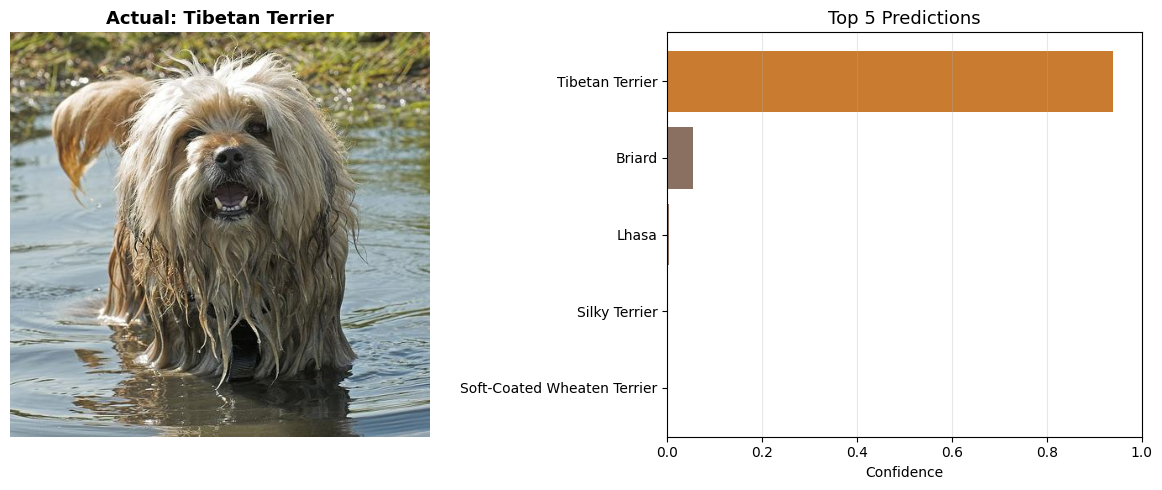


🔍 Top predictions:
  ✅ 1. Tibetan Terrier                          93.9%
     2. Briard                                   5.4%
     3. Lhasa                                    0.4%
     4. Silky Terrier                            0.1%
     5. Soft-Coated Wheaten Terrier              0.1%


In [26]:
# ============================================================
# CELL 16 — Test Prediction on a Sample Image
# ============================================================
from tensorflow.keras.preprocessing import image as keras_image

def predict_breed(img_path, model, class_indices, top_k=5):
    img = keras_image.load_img(img_path, target_size=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']))
    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr, verbose=0)[0]
    top_indices = preds.argsort()[-top_k:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            'breed': class_indices[str(idx)],
            'confidence': float(preds[idx]),
            'percentage': f'{preds[idx]*100:.1f}%'
        })
    return results

# Load class indices
with open(os.path.join(CONFIG['MODEL_SAVE'], 'class_indices.json')) as f:
    class_idx = json.load(f)

# Test on a random image from test set
test_breed = random.choice(os.listdir(os.path.join(SPLIT_DIR, 'test')))
test_img_dir = os.path.join(SPLIT_DIR, 'test', test_breed)
test_img = os.path.join(test_img_dir, random.choice(os.listdir(test_img_dir)))

predictions = predict_breed(test_img, model, class_idx)

# Show image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
img_display = keras_image.load_img(test_img)
ax1.imshow(img_display); ax1.axis('off')
ax1.set_title(f'Actual: {test_breed}', fontsize=13, fontweight='bold')

breeds_pred = [p['breed'] for p in predictions]
confs_pred  = [p['confidence'] for p in predictions]
colors      = ['#c97c30' if b == test_breed else '#8a7060' for b in breeds_pred]

ax2.barh(breeds_pred[::-1], confs_pred[::-1], color=colors[::-1])
ax2.set_xlabel('Confidence'); ax2.set_title('Top 5 Predictions', fontsize=13)
ax2.set_xlim([0, 1]); ax2.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print('\n🔍 Top predictions:')
for i, p in enumerate(predictions, 1):
    marker = '✅' if p['breed'] == test_breed else '  '
    print(f'  {marker} {i}. {p["breed"]:40s} {p["percentage"]}')

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("pawid_final.keras")  # or .h5
model.summary()

In [ ]:
print(model.name)

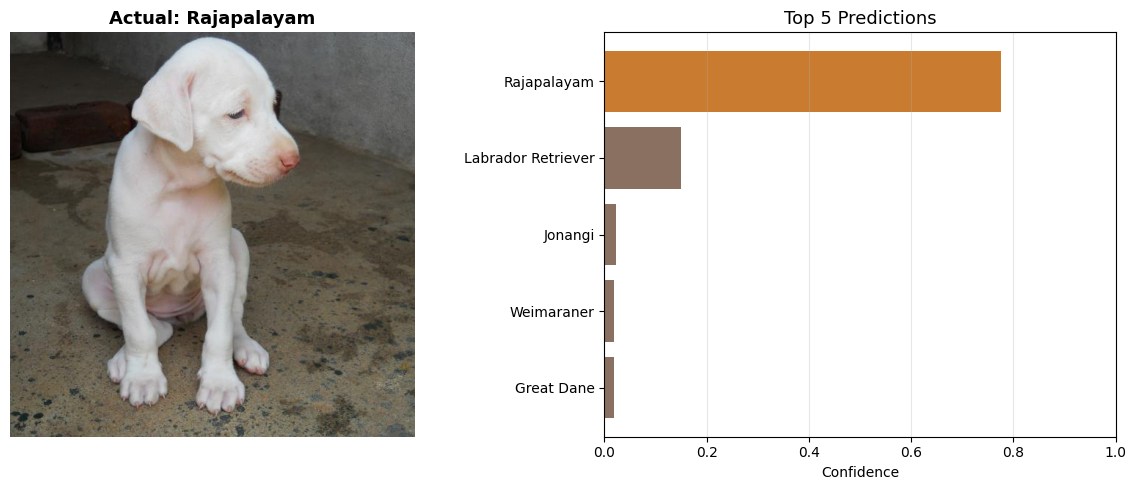


🔍 Top predictions for Rajapalayam:
  ✅ 1. Rajapalayam                              77.7%
     2. Labrador Retriever                       15.0%
     3. Jonangi                                  2.2%
     4. Weimaraner                               2.0%
     5. Great Dane                               1.8%


In [27]:
import random
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image

# Assuming predict_breed function and necessary variables (model, class_idx, CONFIG, SPLIT_DIR) are defined in previous cells

# Test on an image of 'Rajapalayam' from the test set
rajapalayam_breed_name = 'Rajapalayam'
rajapalayam_img_dir = os.path.join(SPLIT_DIR, 'test', rajapalayam_breed_name)

if os.path.exists(rajapalayam_img_dir) and len(os.listdir(rajapalayam_img_dir)) > 0:
    test_img = os.path.join(rajapalayam_img_dir, random.choice(os.listdir(rajapalayam_img_dir)))
    predictions = predict_breed(test_img, model, class_idx)

    # Show image and predictions
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    img_display = keras_image.load_img(test_img)
    ax1.imshow(img_display); ax1.axis('off')
    ax1.set_title(f'Actual: {rajapalayam_breed_name}', fontsize=13, fontweight='bold')

    breeds_pred = [p['breed'] for p in predictions]
    confs_pred  = [p['confidence'] for p in predictions]
    # Highlight if the actual breed is in the predictions
    colors      = ['#c97c30' if b == rajapalayam_breed_name else '#8a7060' for b in breeds_pred]

    ax2.barh(breeds_pred[::-1], confs_pred[::-1], color=colors[::-1])
    ax2.set_xlabel('Confidence'); ax2.set_title('Top 5 Predictions', fontsize=13)
    ax2.set_xlim([0, 1]); ax2.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f'\n🔍 Top predictions for {rajapalayam_breed_name}:')
    for i, p in enumerate(predictions, 1):
        marker = '✅' if p['breed'] == rajapalayam_breed_name else '  '
        print(f'  {marker} {i}. {p["breed"]:40s} {p["percentage"]}')
else:
    print(f"⚠️  No images found for '{rajapalayam_breed_name}' in the test set at {rajapalayam_img_dir}.")
    print("Please ensure the breed was successfully added and split into the test set.")